In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# загрузка
df = pd.read_csv("dataset.csv", sep=";")

# приведение типов
df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y", errors="coerce")

def to_float(s):
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

df["time_on_site_s"] = to_float(df["time_on_site_s"])
df["purchase_amount"] = to_float(df["purchase_amount"])

num_cols = ["age","pages_visited","converted",
            "num_items","delivery_time_days","satisfaction"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# первичный осмотр
df.head()


,customer_id,date,age,gender,region,traffic_source,campaign,time_on_site_s,pages_visited,converted,purchase_amount,num_items,delivery_time_days,satisfaction
0,2295,2025-01-01,30,Male,South,Organic,NaN,373.7,8,1,43.00,5,9,4.0
1,2903,2025-01-01,55,Female,South,PaidAds,CAMP3,1407.9,3,1,294.00,3,12,5.0
2,1922,2025-01-01,21,Female,North,Referral,NaN,493.0,5,1,81.55,4,14,4.0
3,3627,2025-01-01,44,Male,South,Organic,NaN,784.2,13,1,60.45,2,5,3.0
4,2605,2025-01-01,22,Male,East,Organic,NaN,1090.9,9,1,45.87,4,1,4.0


In [4]:
# Описание столбцов 
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean()*100).round(2),
    "unique": df.nunique()
})

summary


,dtype,missing,missing_%,unique
customer_id,int64,0,0.00,5000
date,datetime64[ns],0,0.00,180
age,int64,0,0.00,65
gender,object,0,0.00,3
region,object,0,0.00,4
traffic_source,object,0,0.00,4
campaign,object,3449,68.98,7
time_on_site_s,float64,0,0.00,3615
pages_visited,int64,0,0.00,17
converted,int64,0,0.00,2


In [ ]:
# Классификация
classification = pd.DataFrame({
    "variable": df.columns,
    "type": [
        "ID (категориальная)",
        "временная",
        "количественная (дискретная)",
        "категориальная",
        "категориальная",
        "категориальная",
        "категориальная",
        "количественная (непрерывная)",
        "количественная (дискретная)",
        "бинарная",
        "количественная (непрерывная)",
        "количественная (дискретная)",
        "количественная (дискретная)",
        "порядковая"
    ]
})

classification


,variable,type
0,customer_id,ID (категориальная)
1,date,временная
2,age,количественная (дискретная)
3,gender,категориальная
4,region,категориальная
5,traffic_source,категориальная
6,campaign,категориальная
7,time_on_site_s,количественная (непрерывная)
8,pages_visited,количественная (дискретная)
9,converted,бинарная


In [6]:
# Статистика для ключевых

key_vars = ["purchase_amount",
            "time_on_site_s",
            "pages_visited",
            "delivery_time_days",
            "satisfaction"]

rows = []

for col in key_vars:
    x = df[col].dropna()
    mean_ = x.mean()
    median_ = x.median()
    var_ = x.var(ddof=1)
    cv_ = x.std(ddof=1) / mean_
    rows.append([col, mean_, median_, var_, cv_])

stats_df = pd.DataFrame(
    rows,
    columns=["variable","mean","median","variance","coef_var"]
)

stats_df


,variable,mean,median,variance,coef_var
0,purchase_amount,34.927770,0.00,7615.048930,2.498420
1,time_on_site_s,361.872500,305.45,65282.459298,0.706062
2,pages_visited,5.988400,6.00,5.063678,0.375770
3,delivery_time_days,2.871800,0.00,20.928350,1.592991
4,satisfaction,4.095055,4.00,0.414819,0.157279


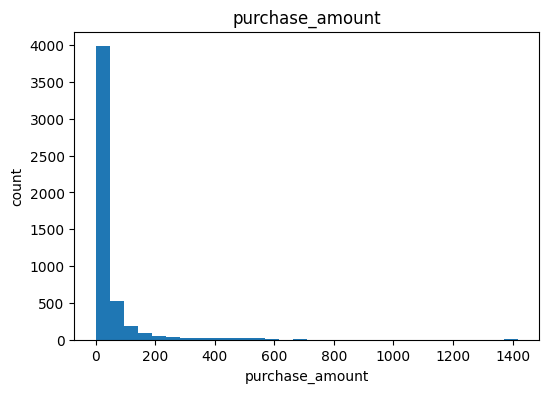

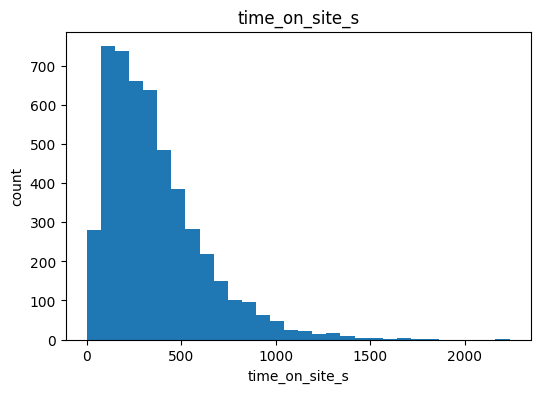

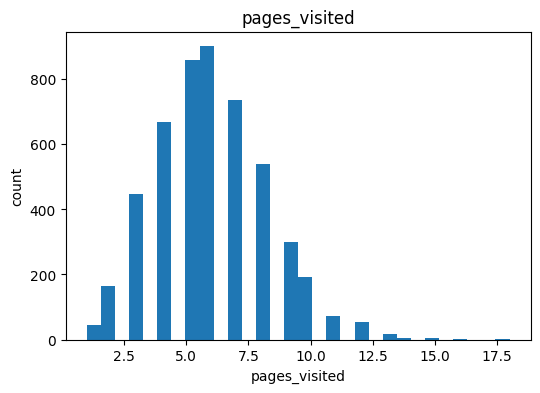

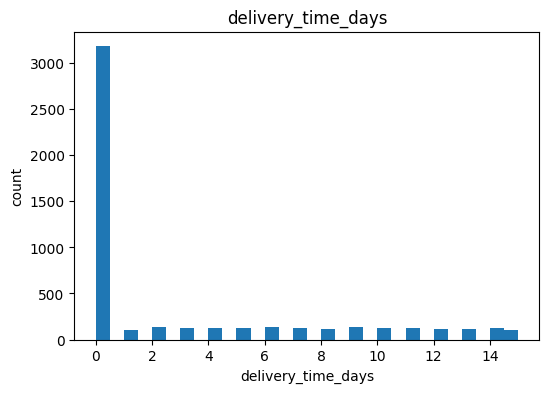

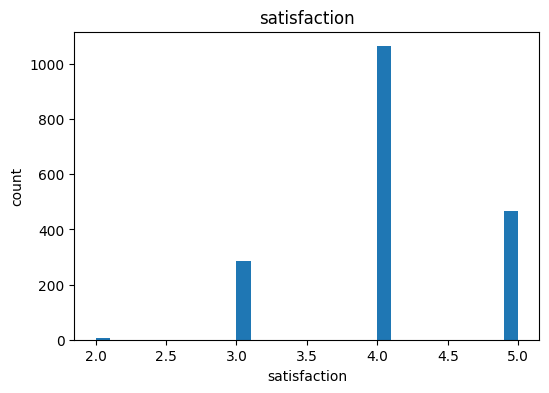

In [8]:
# Гистограммы 

for col in key_vars:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()


In [10]:
N = len(df)
n = 800

# 1) простая случайная
sample_random = df.sample(n=n, random_state=42)

# 2) стратифицированная по region
# распределяю n пропорционально долям region, добиваю до ровно 800
region_counts = df["region"].value_counts()
region_share = region_counts / N
alloc = (region_share * n).round().astype(int)

# чтобы сумма была ровно 800
diff = n - alloc.sum()
if diff != 0:
    # добавляю/убираю по 1 из самых крупных страт
    order = region_counts.index.tolist()
    step = 1 if diff > 0 else -1
    for i in range(abs(diff)):
        alloc[order[i % len(order)]] += step

parts = []
for reg, k in alloc.items():
    part = df[df["region"] == reg].sample(n=int(k), random_state=42)
    parts.append(part)

sample_strat = pd.concat(parts, ignore_index=True)

# 3) систематическая (шаг = floor(N/800))
k = N // n
start = 0  # можно поставить np.random.randint(0, k) если хочешь рандомный старт
sample_sys = df.iloc[start::k].head(n).copy()

# метрики
def calc_metrics(d: pd.DataFrame) -> dict:
    return {
        "mean_purchase_amount": d["purchase_amount"].mean(),
        "std_purchase_amount": d["purchase_amount"].std(ddof=1),
        "conversion": d["converted"].mean(),
        "median_purchase_amount": d["purchase_amount"].median(),
    }

metrics_population = calc_metrics(df)
metrics_random = calc_metrics(sample_random)
metrics_strat = calc_metrics(sample_strat)
metrics_sys = calc_metrics(sample_sys)

# сводная таблица
result_B = pd.DataFrame.from_dict(
    {
        "population": metrics_population,
        "simple_random": metrics_random,
        "stratified_region": metrics_strat,
        "systematic": metrics_sys,
    },
    orient="index"
)

result_B

,mean_purchase_amount,std_purchase_amount,conversion,median_purchase_amount
population,34.927770,87.264248,0.36400,0.0
simple_random,29.782212,73.543655,0.33875,0.0
stratified_region,38.427388,98.058277,0.37625,0.0
systematic,34.299800,84.192136,0.36250,0.0


In [11]:
# C) количественная репрезентативность по purchase_amount

mean_pop = df["purchase_amount"].mean()

def rep_table(sample_name: str, d: pd.DataFrame) -> dict:
    mean_s = d["purchase_amount"].mean()
    abs_dev = mean_s - mean_pop
    rel_dev = abs_dev / mean_pop
    return {
        "sample": sample_name,
        "mean_purchase_amount": mean_s,
        "abs_dev": abs_dev,
        "rel_dev": rel_dev,
        "|rel_dev|": abs(rel_dev),
        "std_purchase_amount": d["purchase_amount"].std(ddof=1),
        "conversion": d["converted"].mean()
    }

rep_df = pd.DataFrame([
    rep_table("simple_random", sample_random),
    rep_table("stratified_region", sample_strat),
    rep_table("systematic", sample_sys),
]).sort_values("|rel_dev|").reset_index(drop=True)

rep_df

,sample,mean_purchase_amount,abs_dev,rel_dev,|rel_dev|,std_purchase_amount,conversion
0,systematic,34.299800,-0.627970,-0.017979,0.017979,84.192136,0.36250
1,stratified_region,38.427388,3.499618,0.100196,0.100196,98.058277,0.37625
2,simple_random,29.782212,-5.145557,-0.147320,0.147320,73.543655,0.33875


In [12]:
# кто наиболее репрезентативен по |rel_dev|
best = rep_df.iloc[0]
print("best sample:", best["sample"])
print("|rel_dev|:", best["|rel_dev|"])

best sample: systematic
|rel_dev|: 0.01797910373321852


In [14]:
# D) доверительные интервалы (95%)

alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

# CI для среднего (нормальная аппроксимация через стандартную ошибку)
def ci_mean(d: pd.DataFrame, col: str):
    x = d[col].dropna().to_numpy()
    n = len(x)
    mean_ = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    lo, hi = mean_ - z*se, mean_ + z*se
    return mean_, lo, hi, n

# CI для конверсии (Wald-интервал)
def ci_conv(d: pd.DataFrame, col="converted"):
    x = d[col].dropna().to_numpy()
    n = len(x)
    p = x.mean()
    se = np.sqrt(p*(1-p)/n)
    lo, hi = p - z*se, p + z*se
    lo = max(0, lo)
    hi = min(1, hi)
    return p, lo, hi, n

datasets = {
    "population": df,
    "simple_random": sample_random,
    "stratified_region": sample_strat,
    "systematic": sample_sys
}

# purchase_amount: общий (как в задании)
mean_rows = []
conv_rows = []

for name, d in datasets.items():
    mean_, lo, hi, n = ci_mean(d, "purchase_amount")
    mean_rows.append([name, n, mean_, lo, hi])
    
    p, lo_p, hi_p, n2 = ci_conv(d, "converted")
    conv_rows.append([name, n2, p, lo_p, hi_p])

ci_mean_df = pd.DataFrame(mean_rows, columns=["dataset","n","mean","ci_low","ci_high"])
ci_conv_df = pd.DataFrame(conv_rows, columns=["dataset","n","conversion","ci_low","ci_high"])

ci_mean_df, ci_conv_df

(             dataset     n       mean     ci_low    ci_high
 0         population  5000  34.927770  32.508973  37.346567
 1      simple_random   800  29.782212  24.685991  34.878434
 2  stratified_region   800  38.427388  31.632420  45.222355
 3         systematic   800  34.299800  28.465690  40.133910,
              dataset     n  conversion    ci_low   ci_high
 0         population  5000     0.36400  0.350663  0.377337
 1      simple_random   800     0.33875  0.305954  0.371546
 2  stratified_region   800     0.37625  0.342680  0.409820
 3         systematic   800     0.36250  0.329188  0.395812)

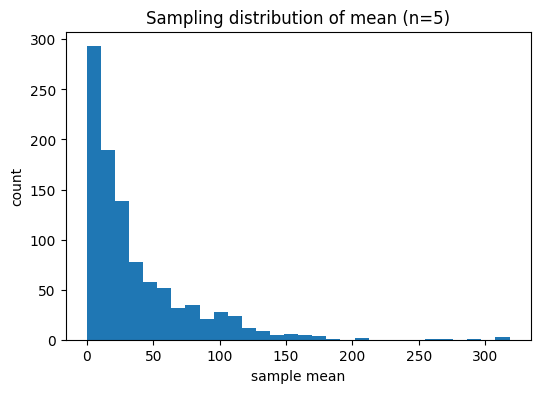

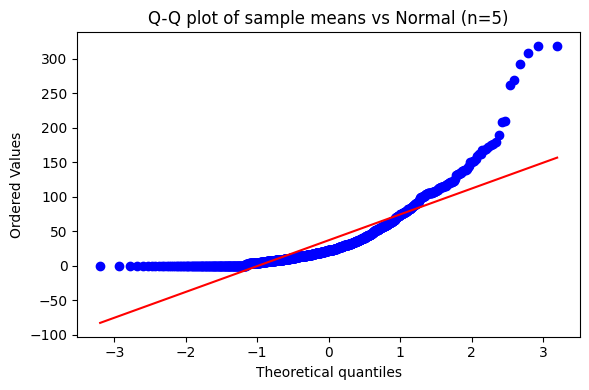

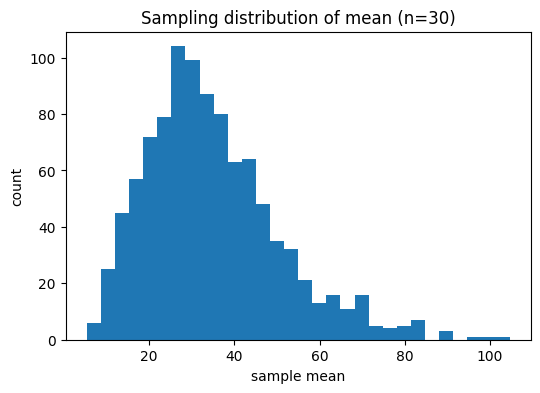

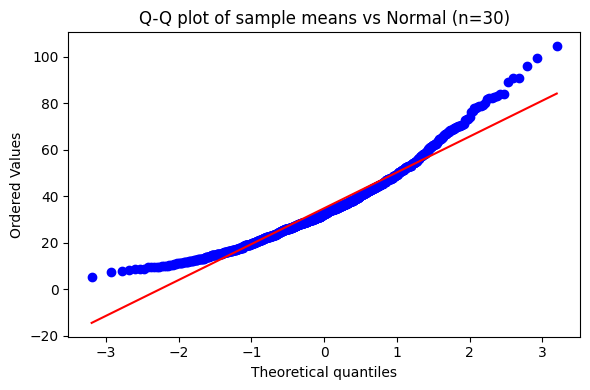

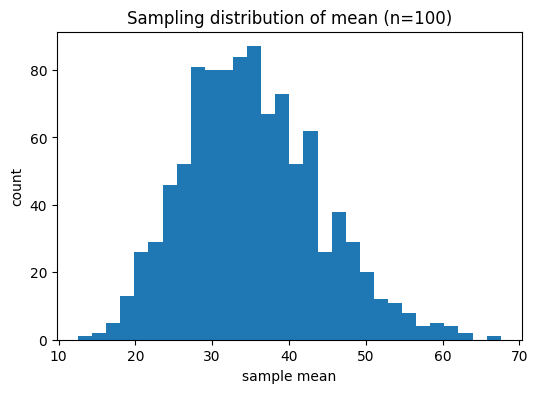

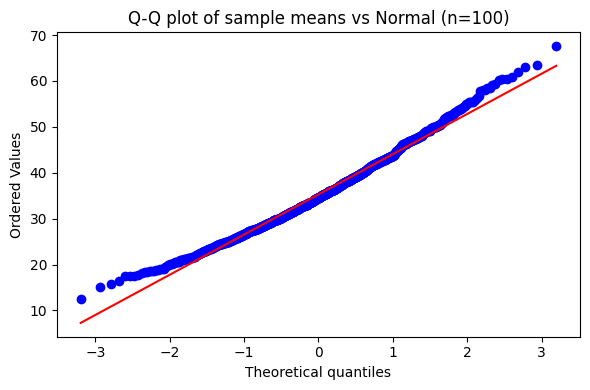

,n,var_of_means
0,5,1325.688444
1,30,272.059019
2,100,76.777006


In [15]:
# E) ЦПТ и Закон больших чисел
# 1000 раз берём подвыборки n = 5, 30, 100 и смотрим распределения средних

rng = np.random.default_rng(42)

x_pop = df["purchase_amount"].dropna().to_numpy()  # как в задании: общий purchase_amount

def simulate_means(x, n, reps=1000):
    idx = rng.integers(0, len(x), size=(reps, n))  # sampling with replacement
    return x[idx].mean(axis=1)

for n in [5, 30, 100]:
    means = simulate_means(x_pop, n, reps=1000)

    # гистограмма средних
    plt.figure(figsize=(6,4))
    plt.hist(means, bins=30)
    plt.title(f"Sampling distribution of mean (n={n})")
    plt.xlabel("sample mean")
    plt.ylabel("count")
    plt.show()

    # Q-Q plot
    plt.figure(figsize=(6,4))
    stats.probplot(means, dist="norm", plot=plt)
    plt.title(f"Q-Q plot of sample means vs Normal (n={n})")
    plt.tight_layout()
    plt.show()

# дисперсия средних по n
vars_ = []
for n in [5, 30, 100]:
    means = simulate_means(x_pop, n, reps=1000)
    vars_.append([n, means.var(ddof=1)])

var_means_df = pd.DataFrame(vars_, columns=["n", "var_of_means"])
var_means_df

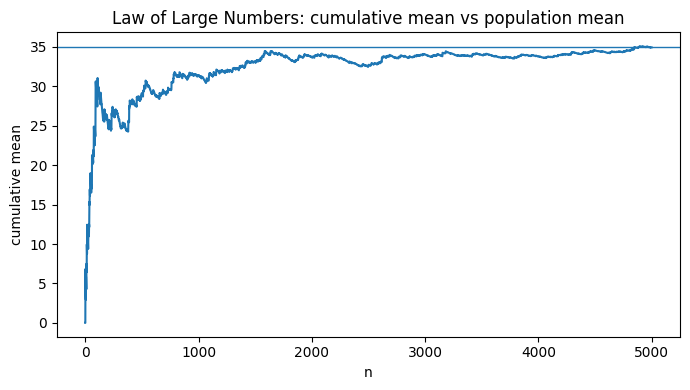

In [16]:
# Закон больших чисел: как стабилизируется среднее при росте n
# (берём одну перестановку и считаем кумулятивное среднее)

x = x_pop.copy()
rng.shuffle(x)

cum_mean = np.cumsum(x) / np.arange(1, len(x) + 1)
true_mean = x_pop.mean()

plt.figure(figsize=(7,4))
plt.plot(cum_mean)
plt.axhline(true_mean, linewidth=1)
plt.title("Law of Large Numbers: cumulative mean vs population mean")
plt.xlabel("n")
plt.ylabel("cumulative mean")
plt.tight_layout()
plt.show()

In [17]:
# F) параметрические оценки для purchase_amount (только покупатели)

x = df.loc[df["converted"] == 1, "purchase_amount"].dropna().to_numpy()
x = x[x > 0]

dists = {
    "lognorm": stats.lognorm,
    "gamma": stats.gamma,
    "weibull_min": stats.weibull_min,
}

fits = {}
for name, dist in dists.items():
    params = dist.fit(x, floc=0)   # MLE, фиксирую loc=0 (для чеков обычно ок)
    fits[name] = params

# сравнение моделей через AIC
def aic(dist, params, x):
    ll = np.sum(dist.logpdf(x, *params))
    k = len(params)
    return 2 * k - 2 * ll

aic_table = []
for name, dist in dists.items():
    params = fits[name]
    aic_table.append([name, aic(dist, params, x)])

aic_df = pd.DataFrame(aic_table, columns=["dist", "AIC"]).sort_values("AIC").reset_index(drop=True)
aic_df

,dist,AIC
0,lognorm,19726.327670
1,gamma,20224.001828
2,weibull_min,20258.265317


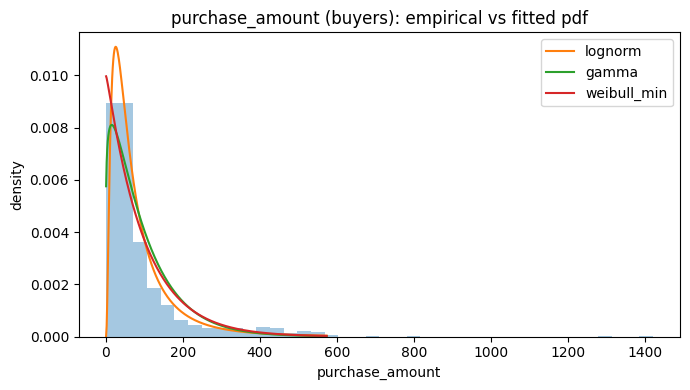

In [18]:
# визуальная проверка: эмпирическая плотность vs теоретическая
grid = np.linspace(x.min(), np.percentile(x, 99.5), 400)

plt.figure(figsize=(7,4))
plt.hist(x, bins=40, density=True, alpha=0.4)
for name, dist in dists.items():
    params = fits[name]
    plt.plot(grid, dist.pdf(grid, *params), label=name)
plt.title("purchase_amount (buyers): empirical vs fitted pdf")
plt.xlabel("purchase_amount")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

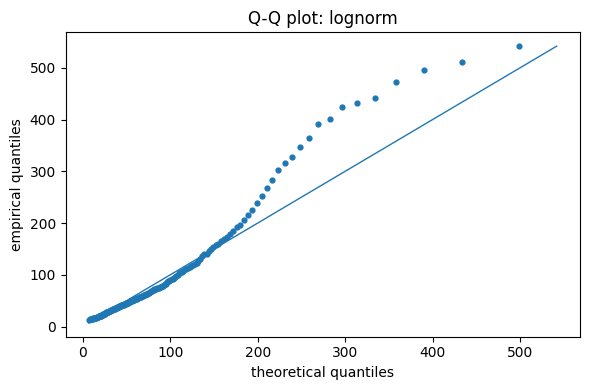

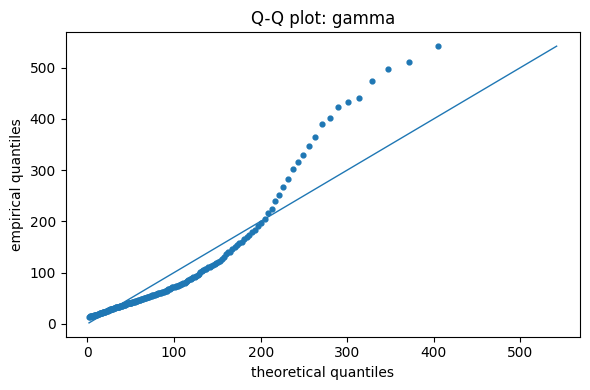

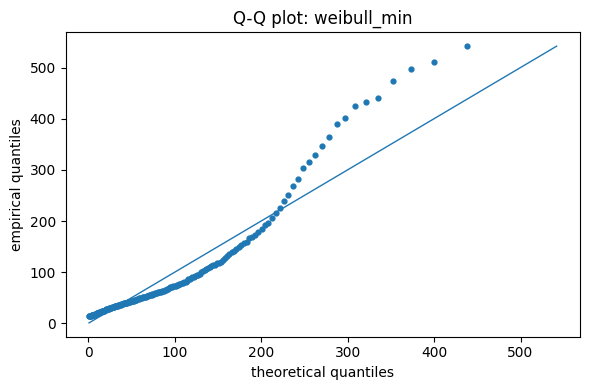

In [19]:
# Q-Q plots для каждой модели
for name, dist in dists.items():
    params = fits[name]
    q = np.linspace(0.01, 0.99, 200)
    theo = dist.ppf(q, *params)
    emp = np.quantile(x, q)

    plt.figure(figsize=(6,4))
    plt.scatter(theo, emp, s=12)
    lo = min(theo.min(), emp.min())
    hi = max(theo.max(), emp.max())
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title(f"Q-Q plot: {name}")
    plt.xlabel("theoretical quantiles")
    plt.ylabel("empirical quantiles")
    plt.tight_layout()
    plt.show()

In [21]:
# G) свойства оценок: смещённость/состоятельность для среднего purchase_amount
# моделирование: берём много выборок разных размеров, сравниваем их среднее с mean ГС

rng = np.random.default_rng(42)

x_pop = df["purchase_amount"].dropna().to_numpy()
mu = x_pop.mean()

def simulate_bias_consistency(x, n, reps=2000):
    idx = rng.integers(0, len(x), size=(reps, n))   # with replacement
    sample_means = x[idx].mean(axis=1)
    errors = sample_means - mu
    return {
        "n": n,
        "mean_of_estimates": sample_means.mean(),
        "bias": errors.mean(),
        "rmse": np.sqrt(np.mean(errors**2)),
        "std_of_estimates": sample_means.std(ddof=1)
    }

rows = []
for n in [10, 50, 200]:
    rows.append(simulate_bias_consistency(x_pop, n))

g_df = pd.DataFrame(rows)
g_df

,n,mean_of_estimates,bias,rmse,std_of_estimates
0,10,35.379171,0.451401,28.411361,28.414880
1,50,35.217134,0.289364,12.594979,12.594804
2,200,34.988195,0.060425,6.322975,6.324268


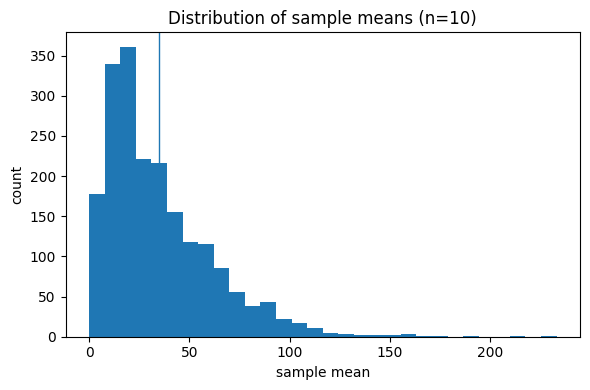

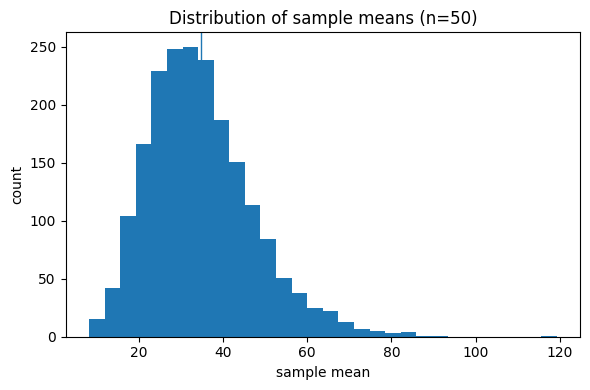

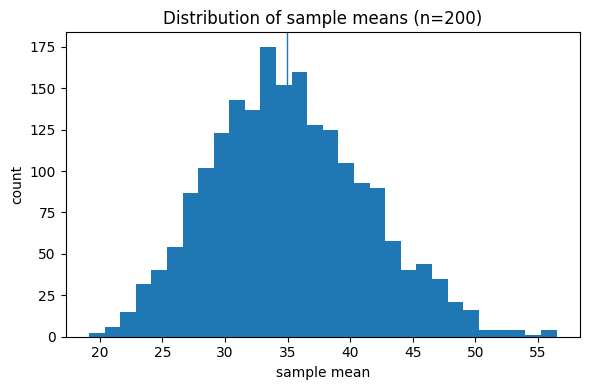

In [22]:
# визуально: распределения оценок среднего при разных n
import matplotlib.pyplot as plt

for n in [10, 50, 200]:
    idx = rng.integers(0, len(x_pop), size=(2000, n))
    means = x_pop[idx].mean(axis=1)

    plt.figure(figsize=(6,4))
    plt.hist(means, bins=30)
    plt.axvline(mu, linewidth=1)
    plt.title(f"Distribution of sample means (n={n})")
    plt.xlabel("sample mean")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

## H. Бизнес-вывод (по данным за 6 месяцев)

### Ключевые метрики
- Объём наблюдений: **5000 визитов**  
- Конверсия в покупку: **36,4%**  
- Средний чек среди покупателей: **≈ 96**  
- Медианный чек среди покупателей: **≈ 53**  
- Средняя оценка удовлетворённости (только покупатели): **≈ 4,1 / 5**  
- Среднее время доставки (только покупатели): **≈ 7,9 дня**  
- Топ-5% покупателей формируют **≈ 26,5%** выручки среди покупателей  

---

### Что влияет на конверсию и средний чек

**1. Поведение на сайте**  
Конверсия резко растёт с увеличением времени на сайте: от **≈ 13%** в нижнем квинтиле времени до **≈ 68%** в верхнем.  
Количество просмотренных страниц оказывает слабое влияние по сравнению с временем на сайте.  

**2. Источник трафика**  
- *Referral* — самая высокая конверсия (**≈ 41%**) и высокая выручка на визит.  
- *PaidAds* — более низкая конверсия (**≈ 35%**), но самый высокий средний чек среди покупателей (**≈ 99**).  

**3. Регионы**  
- *East* — самый высокий средний чек среди покупателей (**≈ 104**), но относительно низкая конверсия (**≈ 35%**).  
- *West* и *South* — более высокая конверсия (**≈ 37–38%**).  

**4. Кампании**  
Поле `campaign` заполнено не полностью (**≈ 69% пропусков**), поэтому выводы по кампаниям ограничены и могут быть смещены.

---

### Рекомендации бизнесу

- Улучшать первые секунды взаимодействия с сайтом (первый экран, скорость загрузки, релевантность посадочных).  
- Масштабировать referral-каналы как источник качественного трафика.  
- Оптимизировать paid-рекламу под рост конверсии, сохраняя ориентацию на высокий средний чек.  
- Для региона East сфокусироваться на росте конверсии (логистика, офферы, локальные акции).  
- Выделить сегмент high-spenders (топ-5%) и проработать персональные предложения.

---

### Риски и ограничения

- Неполное заполнение `campaign`.  
- `satisfaction` доступна только для покупателей.  
- Сильная асимметрия распределения чека (влияние выбросов).  
- Возможная нерепрезентативность отдельных подгрупп.

